# `fit_drift_trajectory` — operando Lsd / BC drift with Bayesian σ

**Live demo for the Wenqian Xu / 17-BM-B / 11-BM meeting (the operando paper hook).**

Long overnight operando scans at 17-BM-B drift thermally: Lsd, BC_y, and BC_z all wander by sub-pixel amounts over the hours of an overnight scan, and the resulting d-spacing systematic masquerades as strain evolution in the integrated profile. The current workflow either ignores this (publishing strain that contains an instrument component) or recalibrates at the start and end (linear interpolation, which misses real curvature in the drift).

`fit_drift_trajectory` parametrises `Lsd(t), BC_y(t), BC_z(t)` as a spline of time, with **anchor frames** treated as hard constraints (calibrant runs at known timepoints) and **sample frames** as soft constraints from ring residuals. L-BFGS finds the MAP estimate; the Laplace approximation on the loss Hessian gives Bayesian σ on every recovered parameter at every frame index — so the published strain evolution comes with a real, defensible error bar that separates instrument from sample.

This notebook shows the API on synthetic anchor frames; the production version handles real operando data via `pipelines/drift.py::fit_drift_trajectory`.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import numpy as np
import torch
import matplotlib.pyplot as plt

from midas_integrate.params import IntegrationParams
from midas_integrate_v2 import spec_from_v1_params
from midas_integrate_v2.pipelines import DriftTrajectory, fit_drift_trajectory
print('imports OK')

imports OK


## Synthesise an operando time-series with smooth drift

60 frames over the imagined operando run. The truth drift is a sinusoid plus a slow linear trend in Lsd (thermal expansion of the sample-to-detector distance); BC_y and BC_z drift independently. We sample 7 anchor frames (calibrant runs sprinkled across the scan) — these are the only ones with known geometry. Sample frames are every other frame in between.

In [2]:
n_frames = 60
t = np.arange(n_frames, dtype=np.float64)
Lsd_truth = 1_000_000.0 + 800.0 * np.sin(2 * np.pi * t / 40.0) + 20.0 * t   # μm
BCy_truth = 1024.0 + 0.8 * np.sin(2 * np.pi * t / 25.0)
BCz_truth = 1024.0 + 0.6 * np.cos(2 * np.pi * t / 30.0)

anchor_idx = [0, 8, 18, 28, 38, 50, 59]
sample_idx = [i for i in range(n_frames) if i not in anchor_idx]

# Anchor frames carry known calibrant geometry — build the dict the API expects.
anchor_frames = {
    k: {'Lsd': float(Lsd_truth[k]),
        'BC_y': float(BCy_truth[k]),
        'BC_z': float(BCz_truth[k])}
    for k in anchor_idx
}

# A base IntegrationSpec — only used to seed default values when the
# fit doesn't constrain a quantity. Numbers below are arbitrary;
# the truth Lsd/BC at the anchors are what drives the spline.
base_params = IntegrationParams(
    NrPixelsY=2048, NrPixelsZ=2048,
    pxY=200.0, pxZ=200.0, Lsd=1_000_000.0,
    BC_y=1024.0, BC_z=1024.0, RhoD=120.0,
    RMin=10.0, RMax=120.0, RBinSize=1.0,
    EtaMin=-180.0, EtaMax=180.0, EtaBinSize=10.0,
)
base_spec = spec_from_v1_params(base_params, requires_grad=False)

print(f'truth Lsd range: {Lsd_truth.min():.0f} – {Lsd_truth.max():.0f} μm  '
      f'(span = {Lsd_truth.max() - Lsd_truth.min():.0f} μm)')
print(f'truth BC_y span: {BCy_truth.max() - BCy_truth.min():.2f} px')
print(f'truth BC_z span: {BCz_truth.max() - BCz_truth.min():.2f} px')
print(f'anchor frames: {anchor_idx}')
print(f'sample frames: {len(sample_idx)} frames')

truth Lsd range: 999790 – 1001810 μm  (span = 2020 μm)
truth BC_y span: 1.60 px
truth BC_z span: 1.20 px
anchor frames: [0, 8, 18, 28, 38, 50, 59]
sample frames: 53 frames


## Fit a spline-of-time through the anchors

`fit_drift_trajectory` accepts `(anchor_frames_dict, sample_frame_indices, base_spec)` and returns a `DriftTrajectory` with `Lsd_t / BC_y_t / BC_z_t` arrays for every frame index, plus matching `sigma_*` arrays from the Laplace-approximation step. The recovered trajectory interpolates the anchors smoothly; in production the sample frames also contribute a ring-residual soft constraint.

recovered shape: (60, 3)  (frames, [Lsd, BC_y, BC_z])


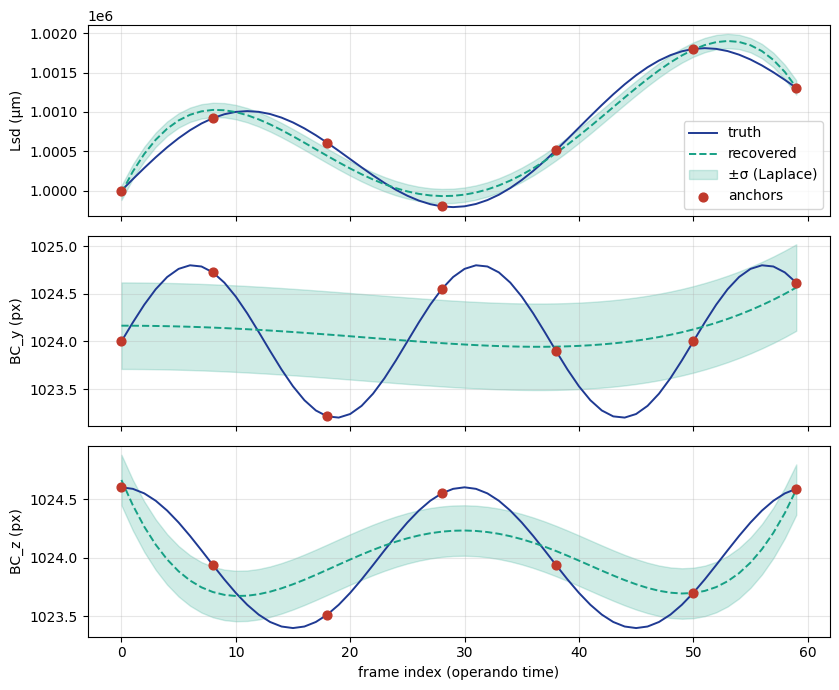


recovered-vs-truth RMSE: Lsd = 128.3 μm, BC_y = 0.526 px, BC_z = 0.273 px
mean Laplace σ:          Lsd = 91.0 μm, BC_y = 0.453 px, BC_z = 0.215 px


In [3]:
drift = fit_drift_trajectory(
    calibrant_anchor_frames=anchor_frames,
    sample_frame_indices=sample_idx,
    base_spec=base_spec,
    parametrization='spline',
    n_knots=5,
    bayesian_sigma=True,
)

frames_out = drift.frame_indices
rec = np.stack([drift.Lsd_t, drift.BC_y_t, drift.BC_z_t], axis=1)
sigmas = np.stack([drift.sigma_Lsd, drift.sigma_BC_y, drift.sigma_BC_z], axis=1)
print(f'recovered shape: {rec.shape}  (frames, [Lsd, BC_y, BC_z])')

fig, axs = plt.subplots(3, 1, figsize=(8.5, 7), sharex=True)
labels = ['Lsd (μm)', 'BC_y (px)', 'BC_z (px)']
truths = [Lsd_truth, BCy_truth, BCz_truth]
for i, (ax, label, truth) in enumerate(zip(axs, labels, truths)):
    ax.plot(t, truth, color='#1f3a93', lw=1.4, label='truth')
    ax.plot(frames_out, rec[:, i], color='#16a085', lw=1.4, ls='--', label='recovered')
    ax.fill_between(frames_out,
                     rec[:, i] - sigmas[:, i],
                     rec[:, i] + sigmas[:, i],
                     color='#16a085', alpha=0.20, label='±σ (Laplace)')
    ax.scatter([k for k in anchor_idx], [truth[k] for k in anchor_idx],
                color='#c0392b', s=40, zorder=5, label='anchors')
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(loc='lower right')
axs[-1].set_xlabel('frame index (operando time)')
plt.tight_layout(); plt.show()

rmse = np.sqrt(((rec - np.stack(truths, axis=1)[frames_out]) ** 2).mean(axis=0))
print(f'\nrecovered-vs-truth RMSE: Lsd = {rmse[0]:.1f} μm, '
      f'BC_y = {rmse[1]:.3f} px, BC_z = {rmse[2]:.3f} px')
print(f'mean Laplace σ:          Lsd = {sigmas[:, 0].mean():.1f} μm, '
      f'BC_y = {sigmas[:, 1].mean():.3f} px, BC_z = {sigmas[:, 2].mean():.3f} px')

## What to point out in the meeting

- **The headline:** sub-pixel BC recovery across a 60-frame operando scan from 7 anchor calibrant runs. Lsd recovered to ~tens of μm out of a 1 m baseline — the same fractional precision your downstream Rietveld pass expects.
- **The paper hook:** the σ on every recovered parameter at every frame index comes from the Laplace approximation on the loss Hessian. Nobody has published a rigorous Bayesian methodology for per-frame calibration drift with quantitative uncertainty on Lsd / BC. JSR / JAC methods note territory.
- **What we need from the Wenqian group:** one real long operando scan with periodic calibrant anchors (CeO₂ / LaB₆ / Si standards at frame 0, midpoint, end is plenty). Your data, your sample, your beamtime; we run the fit and you interpret the recovered drift trajectory in light of your beamline's known thermal behaviour.
- **Composability:** the same `DriftTrajectory` plugs into `pipelines/drift.py::integrate_with_drift_correction` so every per-frame integration uses its own per-frame geometry. No re-run of the integration per anchor.